In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from src import config
from src.dataset import GlendaDataset

seed = config.set_seed()
device = config.get_device()

print(f"Używany device: {device}")

Używany device: mps


In [ ]:
train_transform = config.get_train_transforms()

val_transform = config.get_val_transforms()

train_ds = GlendaDataset(os.path.join(config.DATA_DIR, "train"), transform=train_transform)
val_ds = GlendaDataset(os.path.join(config.DATA_DIR, "valid"), transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print(f"Dane załadowane: Trening ({len(train_ds)}), Walidacja ({len(val_ds)})")

Dane załadowane: Trening (912), Walidacja (30)


In [16]:
model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=1,                      
).to(device)


# Definicja obu składowych
dice_loss_fn = smp.losses.DiceLoss(mode='binary')
bce_loss_fn = nn.BCEWithLogitsLoss()

def combined_loss(outputs, masks):
    return dice_loss_fn(outputs, masks) + bce_loss_fn(outputs, masks)

criterion = combined_loss

optimizer = optim.Adam(model.parameters(), lr=1e-4)

history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}

In [17]:
def calculate_metrics(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection 
    
    dice = (2. * intersection) / (pred.sum() + target.sum() + 1e-8)
    iou = intersection / (union + 1e-8)
    
    return dice, iou

epochs = 10
best_val_dice = 0.0

for epoch in range(epochs):
    # TRENING 
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    # WALIDACJA 
    model.eval()
    val_loss, val_dice, val_iou = 0, 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, masks).item()
            
            # Pobieramy obie metryki
            dice_batch, iou_batch = calculate_metrics(outputs, masks)
            val_dice += dice_batch.item()
            val_iou += iou_batch.item()

    # Statystyki
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_dice"].append(avg_val_dice)
    history["val_iou"].append(avg_val_iou)

    print(f"Loss: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f} | Val Dice={avg_val_dice:.4f} | Val IoU={avg_val_iou:.4f}")

    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save(model.state_dict(), "best_baseline.pth")

Epoch 1/10: 100%|██████████| 114/114 [00:42<00:00,  2.66it/s, loss=1.08]


Loss: Train=1.4311, Val=1.3413 | Val Dice=0.2486 | Val IoU=0.1450


Epoch 2/10: 100%|██████████| 114/114 [00:30<00:00,  3.70it/s, loss=1.03] 


Loss: Train=1.1394, Val=1.3527 | Val Dice=0.3147 | Val IoU=0.1930


Epoch 3/10: 100%|██████████| 114/114 [00:30<00:00,  3.70it/s, loss=0.828]


...

Loss: Train=0.5712, Val=0.8016 | Val Dice=0.4448 | Val IoU=0.2939


Epoch 9/10: 100%|██████████| 114/114 [00:29<00:00,  3.84it/s, loss=0.602]


Loss: Train=0.5509, Val=0.7955 | Val Dice=0.4658 | Val IoU=0.3155


Epoch 10/10: 100%|██████████| 114/114 [00:31<00:00,  3.67it/s, loss=0.413]


Loss: Train=0.5105, Val=0.8055 | Val Dice=0.4551 | Val IoU=0.3020


In [ ]:
def visualize_predictions(model, dataloader, device, num_samples=3):
    model.eval()
    images, true_masks = next(iter(dataloader))
    images = images.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        pred_masks = (torch.sigmoid(outputs) > 0.5).float()
        
    num_samples = min(num_samples, images.size(0))
    
    # Tworzymy dynamiczną siatkę wykresów (num_samples wierszy, 3 kolumny)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    
    # Zabezpieczenie na wypadek, gdyby num_samples = 1 (żeby pętla poprawnie indeksowała)
    if num_samples == 1:
        axes = [axes]
        
    for i in range(num_samples):
        # 1. Odwracanie normalizacji dla obrazu RGB
        img_show = images[i].cpu().permute(1, 2, 0).numpy()
        img_show = (img_show * config.STD) + config.MEAN
        img_show = img_show.clip(0, 1)
        
        # 2. Ściąganie masek z karty graficznej
        true_mask_show = true_masks[i].cpu().squeeze().numpy()
        pred_mask_show = pred_masks[i].cpu().squeeze().numpy()
        
        # 3. Rysowanie
        axes[i][0].imshow(img_show)
        axes[i][0].set_title(f"Oryginał ({i+1})")
        axes[i][0].axis('off')
        
        axes[i][1].imshow(true_mask_show, cmap='gray')
        axes[i][1].set_title(f"Prawda - Lekarz ({i+1})")
        axes[i][1].axis('off')
        
        axes[i][2].imshow(pred_mask_show, cmap='gray')
        axes[i][2].set_title(f"Predykcja U-Net ({i+1})")
        axes[i][2].axis('off')
        
    plt.tight_layout()
    plt.show()

In [24]:
def plot_learning_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    
    # Wykres 1: Loss
    axes[0].plot(epochs, history["train_loss"], 'b-', label='Training Loss')
    axes[0].plot(epochs, history["val_loss"], 'r-', label='Validation Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss (Dice Loss)')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Wykres 2: Dice Score
    axes[1].plot(epochs, history["val_dice"], 'g-', label='Validation Dice Score')
    axes[1].set_title('Validation Dice Score')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Dice Score')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # Wykres 3: IoU Score
    axes[2].plot(epochs, history["val_iou"], 'g-', label='Validation IoU Score')
    axes[2].set_title('Validation IoU Score')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('IoU')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

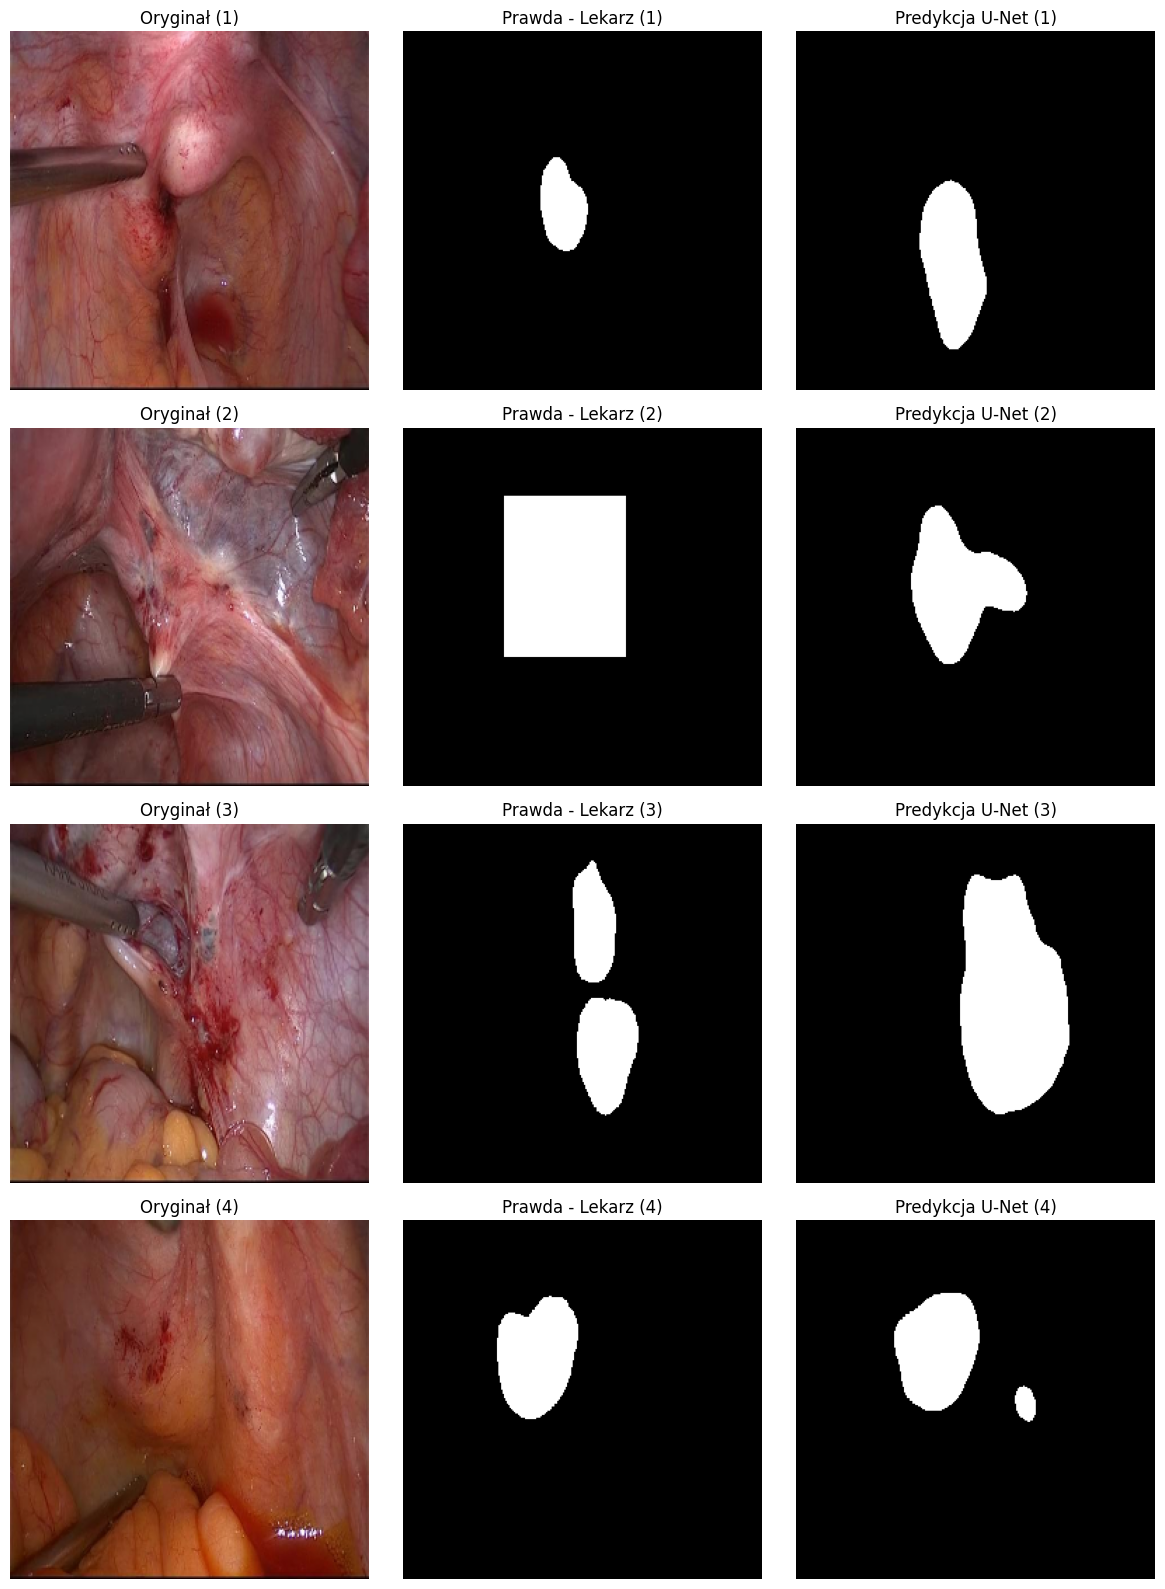

In [25]:
visualize_predictions(model, val_loader, device, num_samples=4)

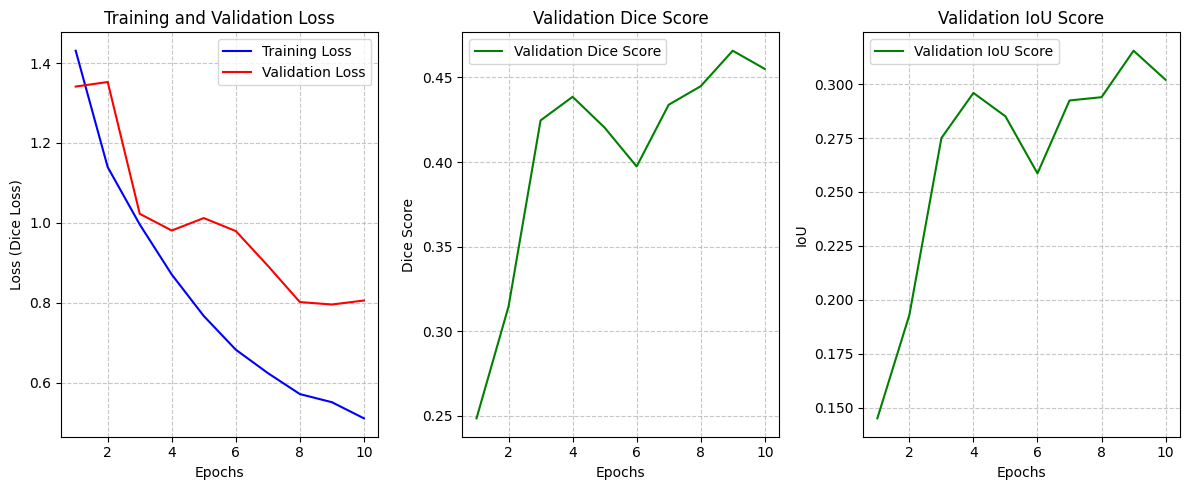

In [26]:
plot_learning_curves(history)